In [1]:
%run -i ./08_sample_mean_and_covariance.ipynb
%matplotlib widget

In [2]:
@write_method(_ContinuousFunction)
def _integrate_once(self, f=None, bounds=None, n_split=None):
  if f is None: f = self.f
  if bounds is None: bounds = self.bounds
  if isinstance(bounds, list): bounds = bounds[0]
  val, err = scipy.integrate.quad(f, *bounds)
  return np.float64(val)

In [3]:
def _unite_bounds(bounds):
  if isinstance(bounds[0], tuple):
    lowers = [b[0] for b in bounds]
    uppers = [b[1] for b in bounds]
    return [(min(lowers), max(uppers))]
  else:
    return [_unite_bounds(group) for group in zip(*bounds)]

In [4]:
def _normalized_product(p1, p2):
  p1p2 = _ContinuousFunction(f=(lambda x: p1(x) * p2(x)),
                             bounds=_unite_bounds([p1.bounds, p2.bounds]))
  n = p1p2.integrate() ** -1
  
  def p(x):
    return n * p1p2(x)
  return p

1.0000000000000002


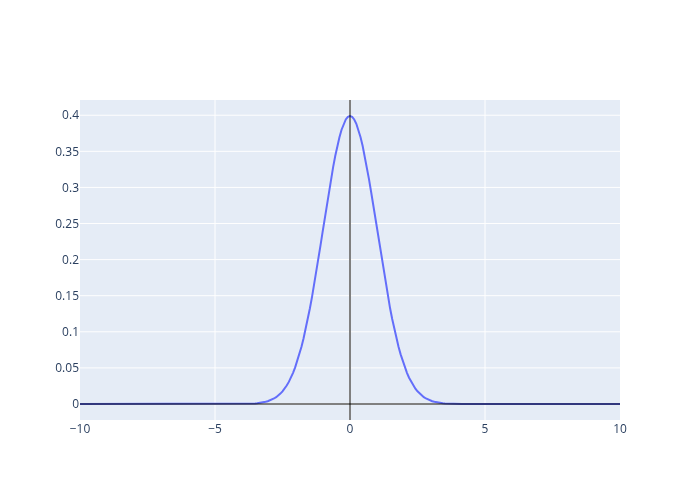

1.0


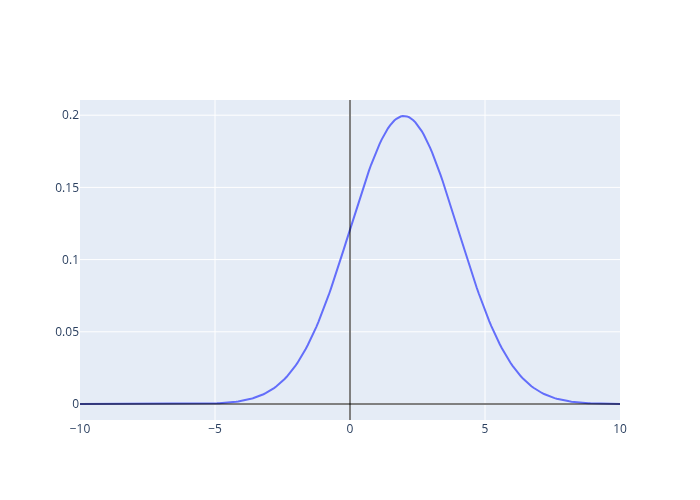

1.0000000000000002


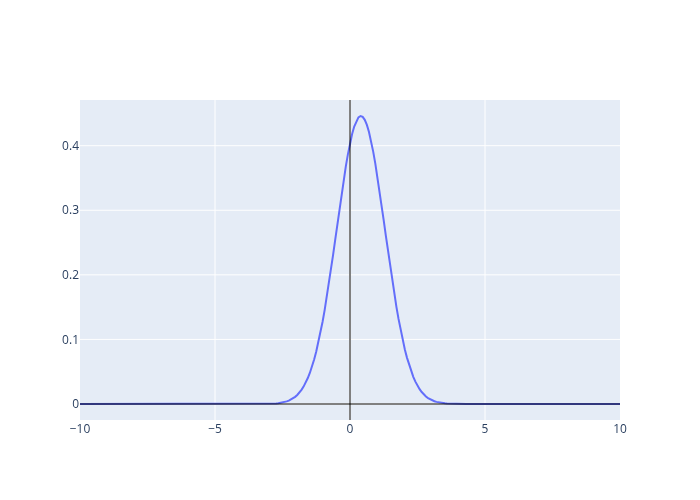

In [5]:
if __name__ == '__main__' and '__file__' not in globals():
  p1 = _ContinuousFunction(f=(lambda x: (_gaussian(0.0, 1.0)(x))),
                           bounds=[(-128.0, 128.0)])
  p2 = _ContinuousFunction(f=(lambda x: (_gaussian(2.0, 2.0)(x))),
                           bounds=[(-128.0, 128.0)])
  print(p1.integrate())
  _plot_function(p1, (-10.0, 10.0))
  print(p2.integrate())
  _plot_function(p2, (-10.0, 10.0))
  p1p2 = _ContinuousFunction(f=(lambda x: (_normalized_product(p1, p2)(x))),
                             bounds=_unite_bounds([p1.bounds, p2.bounds]))
  print(p1p2.integrate())
  _plot_function(_normalized_product(p1, p2), (-10.0, 10.0))